### **Executive Summary: Key Drivers of Customer Attrition**

This analysis identifies three primary "Red Flags" that predict whether a customer will leave (**Churn**) or stay. By understanding these patterns, the business can shift from reacting to losses to proactively preventing them.

---

* **1. The Payment Risk (Electronic Checks):**
Customers using **Electronic Checks** are the highest-risk group with a **45.3% churn rate**. This is nearly **3x higher** than customers on automated billing (15%). This suggests that manual payment processes create "friction" that leads to higher exit rates.
* **2. The Loyalty Threshold (Service Bundling):**
Providing just one support service (like Tech Support) is not enough. We discovered a **"Double-Anchor" effect**: churn risk stays high at 32% with only one service but drops drastically to **15%** the moment a customer adopts **two or more** services. Customers with a full suite of services are the most "sticky" (only 6.8% churn).
* **3. The Contract Stability (Month-to-Month vs. Long-Term):**
Contract type is the strongest predictor of loyalty. **Month-to-Month** customers are highly volatile and prone to leaving, while **Two-Year contracts** act as a total stabilizer, reducing churn to its lowest possible levels.

---

**Strategic Conclusion:** To save the most customers, the company should focus on migrating **Month-to-Month Electronic Check** users into **Multi-Service Bundles** with automated billing.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Import required libraries


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset


In [3]:
df1 = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df1.copy()

# Explore the data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['customerID'].nunique()

7043

In [7]:
df.drop(['customerID'],axis = 1,inplace = True)

In [8]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
for cols in df.columns:
    if(df[cols].dtype == 'object'):
        print(cols,df[cols].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn ['No' 'Yes']


In [10]:
for cols in df.columns:
    if(df[cols].dtype == 'int64'):
        print(cols,df[cols].nunique())

SeniorCitizen 2
tenure 73


In [11]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [12]:
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()


In [13]:
df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})


In [14]:
df.groupby("SeniorCitizen")['Churn'].value_counts()

SeniorCitizen  Churn
0              0        4508
               1        1393
1              0         666
               1         476
Name: count, dtype: int64

In [15]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [16]:
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df[col] = df[col].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})


In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [19]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='SeniorCitizen'>

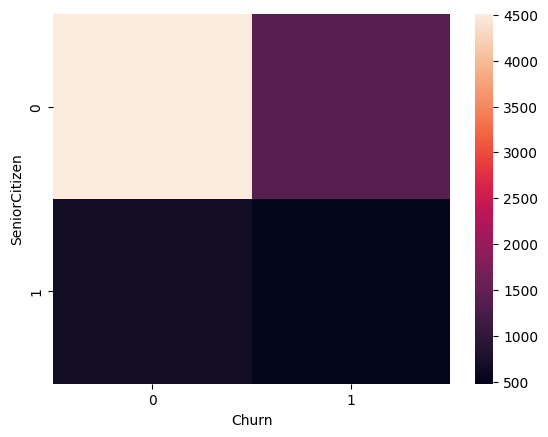

In [20]:
sns.heatmap(df.groupby("SeniorCitizen")['Churn'].value_counts().unstack())

In [21]:
df.groupby("gender")['Churn'].value_counts()

gender  Churn
Female  0        2549
        1         939
Male    0        2625
        1         930
Name: count, dtype: int64

In [22]:
df.groupby("PhoneService")['Churn'].value_counts()

PhoneService  Churn
0             0         512
              1         170
1             0        4662
              1        1699
Name: count, dtype: int64

In [23]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df["PhoneService"], df["Churn"])
print(chi2_contingency(table))


Chi2ContingencyResult(statistic=np.float64(0.9150329892546948), pvalue=np.float64(0.3387825358066928), dof=1, expected_freq=array([[ 501.01774812,  180.98225188],
       [4672.98225188, 1688.01774812]]))


In [24]:
df.groupby("MultipleLines")['Churn'].value_counts()


MultipleLines     Churn
No                0        2541
                  1         849
No phone service  0         512
                  1         170
Yes               0        2121
                  1         850
Name: count, dtype: int64

In [25]:
chi2_contingency(pd.crosstab(df['MultipleLines'],df['Churn']))

Chi2ContingencyResult(statistic=np.float64(11.33044148319756), pvalue=np.float64(0.0034643829548773), dof=2, expected_freq=array([[2490.39613801,  899.60386199],
       [ 501.01774812,  180.98225188],
       [2182.58611387,  788.41388613]]))

In [26]:
table11 = pd.crosstab(df["PhoneService"], df["MultipleLines"])
chi2_1, p_1, dof_1, _ = chi2_contingency(table11)
print("PhoneService vs MultipleLines")
print(table11)
print(f"Chi2 = {chi2_1:.3f}, p = {p_1:.3f}\n")

PhoneService vs MultipleLines
MultipleLines    No  No phone service   Yes
PhoneService                               
0                 0               682     0
1              3390                 0  2971
Chi2 = 7043.000, p = 0.000



In [27]:
(df[df['InternetService'].isin(['DSL', 'Fiber Optic','No'])][['StreamingTV','StreamingMovies']].value_counts())


StreamingTV          StreamingMovies    
No internet service  No internet service    1526
No                   No                     1113
Yes                  Yes                     630
No                   Yes                     351
Yes                  No                      327
Name: count, dtype: int64

In [28]:
df.groupby("TechSupport")['Churn'].value_counts()

TechSupport          Churn
No                   0        2027
                     1        1446
No internet service  0        1413
                     1         113
Yes                  0        1734
                     1         310
Name: count, dtype: int64

In [29]:
chi2_contingency(pd.crosstab(df['TechSupport'],df['Churn']))

Chi2ContingencyResult(statistic=np.float64(828.1970684587394), pvalue=np.float64(1.4430840279998987e-180), dof=2, expected_freq=array([[2551.37043873,  921.62956127],
       [1121.04557717,  404.95442283],
       [1501.5839841 ,  542.4160159 ]]))

In [30]:
df.groupby(["OnlineBackup",'OnlineSecurity'])['Churn'].mean()

OnlineBackup         OnlineSecurity     
No                   No                     0.481549
                     Yes                    0.197088
No internet service  No internet service    0.074050
Yes                  No                     0.310054
                     Yes                    0.105684
Name: Churn, dtype: float64

In [31]:
chi2_contingency(pd.crosstab([df['OnlineBackup'],df['OnlineSecurity']],df['Churn']))

Chi2ContingencyResult(statistic=np.float64(994.6937508916055), pvalue=np.float64(5.041132839246404e-214), dof=4, expected_freq=array([[1612.51313361,  582.48686639],
       [ 656.02470538,  236.97529462],
       [1121.04557717,  404.95442283],
       [ 957.22305836,  345.77694164],
       [ 827.19352549,  298.80647451]]))

# Check wether the payment method leads to churn

In [32]:
df.groupby("PaymentMethod")['Churn'].value_counts()

PaymentMethod              Churn
Bank transfer (automatic)  0        1286
                           1         258
Credit card (automatic)    0        1290
                           1         232
Electronic check           0        1294
                           1        1071
Mailed check               0        1304
                           1         308
Name: count, dtype: int64

In [33]:
chi2_contingency(pd.crosstab(df['PaymentMethod'],df['Churn']))

Chi2ContingencyResult(statistic=np.float64(648.1423274814), pvalue=np.float64(3.6823546520097993e-140), dof=3, expected_freq=array([[1134.26891949,  409.73108051],
       [1118.10705665,  403.89294335],
       [1737.40025557,  627.59974443],
       [1184.22376828,  427.77623172]]))

<Axes: ylabel='count'>

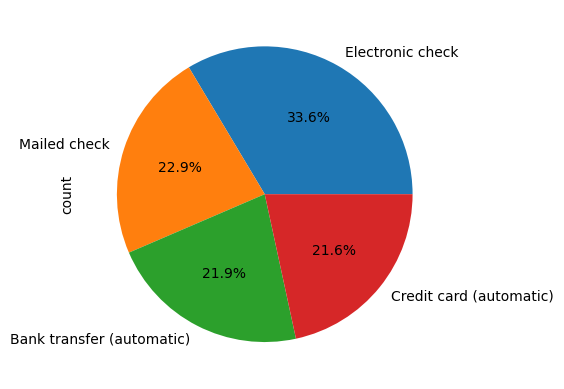

In [34]:
df['PaymentMethod'].value_counts().plot(kind = 'pie',autopct='%1.1f%%')

# Insight from the Payment VS Churn
**From the Above analysis, plots and by using statistical test we can say that- 45.2% of electronic check payment user are highly prone to churn**

In [35]:
df.groupby("Contract")['Churn'].value_counts()

Contract        Churn
Month-to-month  0        2220
                1        1655
One year        0        1307
                1         166
Two year        0        1647
                1          48
Name: count, dtype: int64

# Check the relation between the tenure and Churn

In [36]:
df.tenure.max()

72

<Axes: >

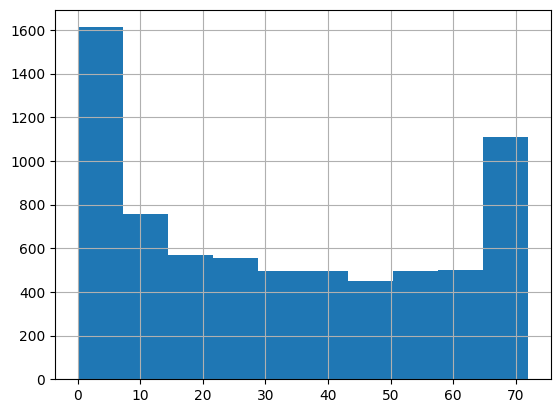

In [37]:
df['tenure'].hist(bins=10)

In [38]:

bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0–1 yr', '1–2 yr', '2–3 yr', '3–4 yr', '4–5 yr', '5–6 yr']

df['tenure_bin'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True, include_lowest=True)


In [39]:
table = pd.crosstab(df['tenure_bin'], df['PaymentMethod'])
table


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
tenure_bin,,,,
0–1 yr,229,225,978,754
1–2 yr,177,181,380,286
2–3 yr,182,188,284,178
3–4 yr,194,191,236,141
4–5 yr,239,225,247,121
5–6 yr,523,512,240,132


In [40]:
prop = table.apply(lambda x: x / x.sum(), axis=1)
prop


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
tenure_bin,,,,
0–1 yr,0.104758,0.102928,0.447392,0.344922
1–2 yr,0.172852,0.176758,0.371094,0.279297
2–3 yr,0.218750,0.225962,0.341346,0.213942
3–4 yr,0.254593,0.250656,0.309711,0.185039
4–5 yr,0.287260,0.270433,0.296875,0.145433
5–6 yr,0.371713,0.363895,0.170576,0.093817


<Figure size 1500x1500 with 0 Axes>

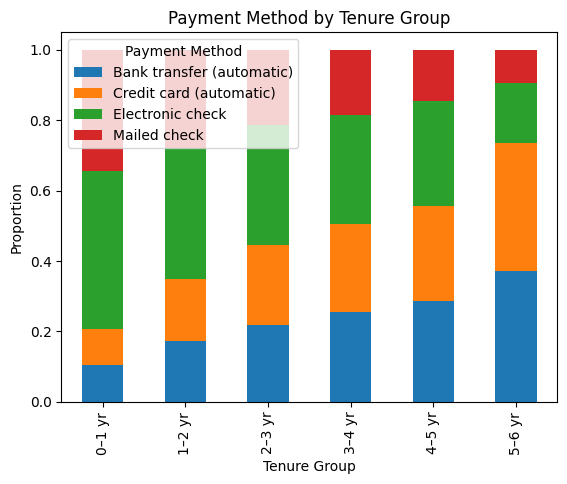

In [41]:
plt.figure(figsize = (15,15))
prop.plot(kind='bar', stacked=True)
plt.title('Payment Method by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Proportion')
plt.legend(title='Payment Method')
plt.show()


In [42]:
prop.loc['0–1 yr']
prop.loc['5–6 yr']


PaymentMethod
Bank transfer (automatic)    0.371713
Credit card (automatic)      0.363895
Electronic check             0.170576
Mailed check                 0.093817
Name: 5–6 yr, dtype: float64

In [43]:
df.groupby("tenure_bin")['TechSupport'].value_counts()

/tmp/ipykernel_17/1467749831.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tenure_bin")['TechSupport'].value_counts()


tenure_bin  TechSupport        
0–1 yr      No                     1390
            No internet service     513
            Yes                     283
1–2 yr      No                      569
            No internet service     239
            Yes                     216
2–3 yr      No                      414
            Yes                     248
            No internet service     170
3–4 yr      No                      351
            Yes                     244
            No internet service     167
4–5 yr      No                      365
            Yes                     306
            No internet service     161
5–6 yr      Yes                     747
            No                      384
            No internet service     276
Name: count, dtype: int64

In [44]:
y = df.groupby("tenure_bin")['TechSupport'].value_counts().unstack()

/tmp/ipykernel_17/1067045800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y = df.groupby("tenure_bin")['TechSupport'].value_counts().unstack()


<Axes: xlabel='tenure_bin'>

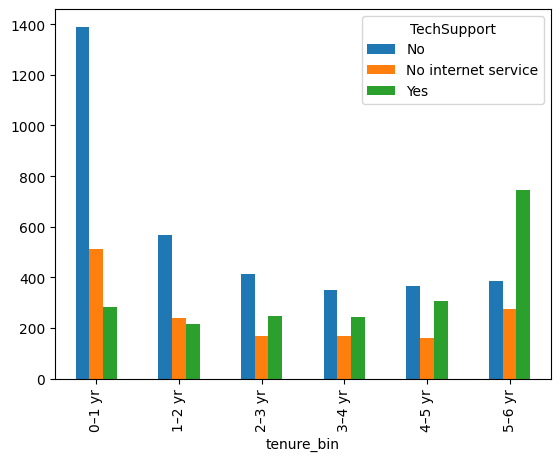

In [45]:
y.plot(kind = 'bar')

In [46]:
table = pd.crosstab(df['tenure_bin'], df['TechSupport'])
prop = table.apply(lambda x: x / x.sum(), axis=1)
prop


TechSupport,No,No internet service,Yes
tenure_bin,,,
0–1 yr,0.635865,0.234675,0.129460
1–2 yr,0.555664,0.233398,0.210938
2–3 yr,0.497596,0.204327,0.298077
3–4 yr,0.460630,0.219160,0.320210
4–5 yr,0.438702,0.193510,0.367788
5–6 yr,0.272921,0.196162,0.530917


 # Insight: Contract Duration vs. Retention
 Our analysis confirms that **Month-to-Month contracts** are the primary driver of attrition, exhibiting significantly higher churn compared to long-term commitments; conversely, **Two-Year contracts** act as a powerful stabilizer, reducing churn probability to its lowest levels and confirming that tenure security is directly proportional to customer loyalty.

# Check the relation bewtween the Multiple Services and Churn

In [47]:
df.groupby(['OnlineSecurity', 'OnlineBackup', 'TechSupport'])['Churn'].value_counts().unstack()


Churn                                                           0    1
OnlineSecurity      OnlineBackup        TechSupport                   
No                  No                  No                    788  925
                                        Yes                   350  132
                    Yes                 No                    515  325
                                        Yes                   384   79
No internet service No internet service No internet service  1413  113
Yes                 No                  No                    359  124
                                        Yes                   358   52
                    Yes                 No                    365   72
                                        Yes                   642   47

In [48]:
table = (
    df.groupby(['OnlineSecurity','OnlineBackup','TechSupport'])['Churn']
      .value_counts(normalize=True)
      .unstack()
)

table


Churn                                                               0  \
OnlineSecurity      OnlineBackup        TechSupport                     
No                  No                  No                   0.460012   
                                        Yes                  0.726141   
                    Yes                 No                   0.613095   
                                        Yes                  0.829374   
No internet service No internet service No internet service  0.925950   
Yes                 No                  No                   0.743271   
                                        Yes                  0.873171   
                    Yes                 No                   0.835240   
                                        Yes                  0.931785   

Churn                                                               1  
OnlineSecurity      OnlineBackup        TechSupport                    
No                  No                  No                   0.539988  
                                        Yes                  0.273859  
                    Yes                 No                   0.386905  
                                        Yes                  0.170626  
No internet service No internet service No internet service  0.074050  
Yes                 No                  No                   0.256729  
                                        Yes                  0.126829  
                    Yes                 No                   0.164760  
                                        Yes                  0.068215

In [49]:

cols_to_count = ['TechSupport', 'OnlineBackup', 'OnlineSecurity']


df['Service_count'] = df[cols_to_count].apply(lambda x: x == 'Yes').sum(axis=1)


print(df.groupby('Service_count')['Churn'].mean())

Service_count
0    0.320469
1    0.321884
2    0.154962
3    0.068215
Name: Churn, dtype: float64


# Insight from Multiple Services Vs Churn
**From the above analysis we can say that- If company does not provides OnlineBackup, OnlineSecurity, Techsupport to their customer nearly 33% of their customer are prone to Churn**

<Axes: xlabel='InternetService'>

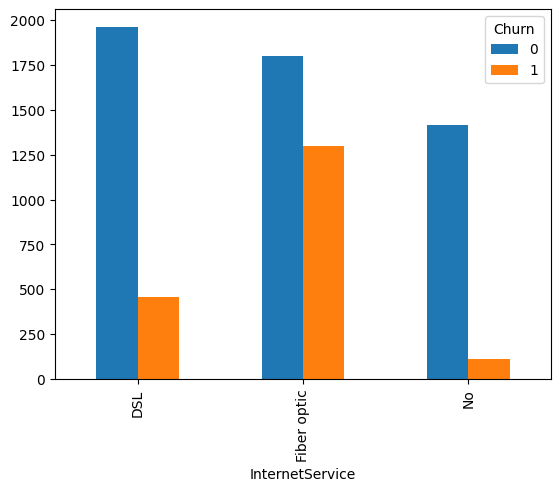

In [50]:
df.groupby(['InternetService'])['Churn'].value_counts().unstack().plot(kind = 'bar')

In [51]:
pd.crosstab(df['InternetService'],df['Churn'])

Churn,0,1
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


<Axes: >

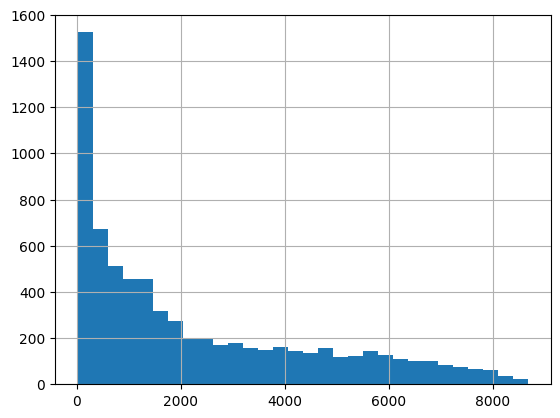

In [52]:
df['TotalCharges'].hist(bins = 30)

In [53]:
df['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [54]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_bin',
       'Service_count'],
      dtype='object')

In [55]:
df.groupby("DeviceProtection")['Churn'].value_counts()

DeviceProtection     Churn
No                   0        1884
                     1        1211
No internet service  0        1413
                     1         113
Yes                  0        1877
                     1         545
Name: count, dtype: int64

In [56]:
chi2_contingency(pd.crosstab(df['DeviceProtection'],df['Churn']))

Chi2ContingencyResult(statistic=np.float64(558.419369407389), pvalue=np.float64(5.505219496457244e-122), dof=2, expected_freq=array([[2273.68024989,  821.31975011],
       [1121.04557717,  404.95442283],
       [1779.27417294,  642.72582706]]))

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   int64   
 3   Dependents        7043 non-null   int64   
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   int64   
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   int64   
 16  PaymentMethod     7043 n